In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_kpi_by_rsrp_bin(file_path, custom_bin_size=5, print_on=False):
    if print_on: print(f"\n📂 분석 시작: 파일명 ➤ **{file_path}**")

    # ============================
    # 1. 데이터 로드 및 KPI 컬럼 정리
    # ============================
    df_raw = pd.read_excel(file_path, sheet_name="Sheet1")
    df_initial_cut = df_raw.filter(regex="^(TIME_STAMP|LTE KPI PCell )")
    df_initial_cut.columns = [
        col if col == "TIME_STAMP" else col.replace("LTE KPI PCell ", "")
        for col in df_initial_cut.columns
    ]

    # ======================================
    # 2. 시험망 PCI=1만 필터링
    # ======================================
    df_initial_cut = df_initial_cut[df_initial_cut["Serving PCI"] == 1].reset_index(drop=True)
    df_initial_cut = df_initial_cut[df_initial_cut["Serving EARFCN(DL)"] == 9560].reset_index(drop=True)
    df_initial_cut = df_initial_cut[df_initial_cut["Serving Band"] == 'Band 28'].reset_index(drop=True)
    df_main_kpi_only = df_initial_cut.copy()
    df_rsrp_for_binning = df_main_kpi_only.sort_values(by="TIME_STAMP").dropna(axis=1, how="all").reset_index(drop=True)

    # ======================================
    # 3. RSRP 급변 감지 및 필터 생성
    # ======================================
    df_main_kpi_only = df_main_kpi_only.sort_values(by="TIME_STAMP").reset_index(drop=True)
    diff_rsrp = df_main_kpi_only["Serving RSRP [dBm]"].diff().fillna(0)
    df_main_kpi_only["RSRP_Break_Flag"] = diff_rsrp > 1

    filter_flags = []
    current_state = True
    last_valid_rsrp = df_main_kpi_only["Serving RSRP [dBm]"].iloc[0]

    for _, row in df_main_kpi_only.iterrows():
        rsrp = row["Serving RSRP [dBm]"]
        is_break = row["RSRP_Break_Flag"]

        if is_break:
            current_state = False
        if not current_state and rsrp < last_valid_rsrp:
            current_state = True
        if current_state:
            last_valid_rsrp = rsrp

        filter_flags.append(current_state)

    df_main_kpi_only["Filter"] = filter_flags

    # ======================================
    # 🚫 3-1. 약전계 이상치 제거
    # ======================================
    null_index = df_main_kpi_only["DL MCS0"].isnull().idxmax()  # 최초 NaN의 index
    
    if pd.isnull(df_main_kpi_only["DL MCS0"]).any():
        df_main_kpi_only = df_main_kpi_only.iloc[:null_index].reset_index(drop=True)

    mcs_values = df_main_kpi_only["DL MCS0"].fillna(0).astype(int).values
    drop_index = len(mcs_values)
    for i in range(1, len(mcs_values)):
        if mcs_values[i-1] == 0 and mcs_values[i] > 0:
            drop_index = i
            break
    
    # drop_index 이후의 데이터 모두 제거
    df_main_kpi_only = df_main_kpi_only.iloc[:drop_index].reset_index(drop=True)


    # ======================================
    # 4. 필터 적용 + NaN-only 컬럼 제거
    # ======================================
    df_filtered_rsrp = df_main_kpi_only[df_main_kpi_only["Filter"] == True].reset_index(drop=True)
    df_rsrp_for_binning = df_filtered_rsrp.sort_values(by="TIME_STAMP").dropna(axis=1, how="all").reset_index(drop=True)
    # df_rsrp_for_binning = df_rsrp_for_binning.iloc[:-2]  # 마지막 2개 행 제거

    # ======================================
    # 5. 시각화: 원본 vs 필터링된 RSRP
    # ======================================
    if print_on:
        fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
        axs[0].plot(
            df_main_kpi_only["TIME_STAMP"],
            df_main_kpi_only["Serving RSRP [dBm]"],
            label="Original",
            color="gray",
            marker="o"
        )
        axs[0].set_title("Original RSRP Over Time")
        axs[0].set_ylabel("RSRP [dBm]")
        axs[0].grid(True)
    
        axs[1].plot(
            df_rsrp_for_binning["TIME_STAMP"],
            df_rsrp_for_binning["Serving RSRP [dBm]"],
            label="Filtered for Binning",
            color="green",
            marker="o"
        )
        axs[1].set_title("Filtered RSRP Over Time (For Binning)")
        axs[1].set_xlabel("Time")
        axs[1].set_ylabel("RSRP [dBm]")
        axs[1].grid(True)
    
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    # ======================================
    # 6. 고정값 (Info) 추출
    # ======================================
    repeated_cols = [col for col in df_initial_cut.columns if df_initial_cut[col].nunique(dropna=True) == 1]
    df_static_info = df_initial_cut[repeated_cols].iloc[:1].copy()
    if print_on: 
        print("\n✅ Basic Info:")
        display(df_static_info)
    
    # ======================================
    # 7. RSRP 1dB Binning 및 Pivot Table 생성
    # ======================================

    # ✅ 1단계: 1dB 단위 Binning
    min_rsrp = int(df_rsrp_for_binning["Serving RSRP [dBm]"].min())
    max_rsrp = int(df_rsrp_for_binning["Serving RSRP [dBm]"].max())

    bin_edges_1dB = list(range(min_rsrp - 1, max_rsrp + 2))
    labels_1dB = [f"{bin_edges_1dB[i+1]} ~ {bin_edges_1dB[i]}" for i in range(len(bin_edges_1dB) - 1)]

    df_rsrp_for_binning["RSRP_Bin_1dB"] = pd.cut(
        df_rsrp_for_binning["Serving RSRP [dBm]"],
        bins=bin_edges_1dB,
        labels=labels_1dB,
        right=True,
        include_lowest=True
    )

    pivot_1dB = (
        df_rsrp_for_binning
        .groupby("RSRP_Bin_1dB", observed=True)
        .mean(numeric_only=True)
        .reset_index()
        .sort_values(by="RSRP_Bin_1dB", ascending=False)
    )
    pivot_1dB = pivot_1dB.reset_index(drop=True)

    # ✅ 사용자 정의 bin size로 재binning
    bin_floor = int((min_rsrp // custom_bin_size - 1) * custom_bin_size)
    bin_ceil = int((max_rsrp // custom_bin_size + 2) * custom_bin_size)
    bin_edges_custom = list(range(bin_floor, bin_ceil + 1, custom_bin_size))
    labels_custom = [f"{bin_edges_custom[i+1]} ~ {bin_edges_custom[i]}" for i in range(len(bin_edges_custom) - 1)]
    pivot_1dB["RSRP_Bin"] = pd.cut(
        pivot_1dB["Serving RSRP [dBm]"],
        bins=bin_edges_custom,
        labels=labels_custom,
        right=True,
        include_lowest=True
    )
    numeric_cols = pivot_1dB.select_dtypes(include="number").columns
    pivot_custom = (
        pivot_1dB
        .groupby("RSRP_Bin", observed=True)[numeric_cols]
        .mean()
        .reset_index()
        .sort_values(by="RSRP_Bin", ascending=False)
    )
    pivot_custom = pivot_custom.reset_index(drop=True)

    if print_on:
        print(f"\n📌 RSRP {custom_bin_size}dB Binning:")
        display(pivot_custom)

    return pivot_custom

In [2]:
# pivot =analyze_kpi_by_rsrp_bin("250615-S25U-IF-All/clean.xlsx", custom_bin_size=1, print_on=True)

In [3]:
### TEST ####
def search_kpi_with_keyword(df):
    kpi_keywords = ["rsrp", "mcs", "rb","prb", "ri2", "rank","ri","bler", "pdsch throughput",'cqi','sinr','rssi','rsrq']
    kpi_candidate_columns = [
        col for col in df.columns
        if any(keyword in col.lower() for keyword in kpi_keywords)
        and "ul" not in col.lower()
        and 'flag' not in col.lower()
        and 'mac' not in col.lower()
        and 'pusch' not in col.lower()
    ]
    final_kpi_columns = [
        col for col in kpi_candidate_columns
    ]    
    display(df[final_kpi_columns].reset_index(drop=True))

# search_kpi_with_keyword(pivot)

In [4]:
def filter_and_rename_kpi(df):
    
    # ✅ 기본 KPI 매핑 정의
    rename_dict = {
        "RSRP_Bin": "LTE_RSRP[dBm]",
        "Serving RSRQ [dB]": "RSRQ[dB]",
        "Serving RSSI [dBm]": "RSSI[dBm]",
        "PDSCH BLER [%]": "DL_BLER[%]",
        "DL MCS0": "DL_MCS",
        "PDSCH PRB Number(Including 0)": "DL_RB_Num",
        "PDSCH Throughput [Mbps]": "DL_Tput[Mbps]",
        "WB CQI CW0": "CQI",
        "WB RI2 Rate": "RI2_Rate[%]",
        "SINR [dB]": "SINR[dB]",

    }

    # ✅ 실제 존재하는 컬럼 중 rename_dict 기준으로 필터링
    columns_to_display = [col for col in rename_dict if col in df.columns]

    # ✅ 출력용 테이블 생성 및 컬럼명 변경
    df_renamed = df[columns_to_display].rename(columns=rename_dict)
    df_renamed = df_renamed.reset_index(drop=True)

    # ✅ 칼럼 순서 지정 (존재하지 않는 항목은 자동 제거)
    final_columns = ['LTE_RSRP[dBm]', "RSRQ[dB]","RSSI[dBm]","SINR[dB]",'DL_Tput[Mbps]', 'DL_MCS', 'DL_BLER[%]',"CQI", 'RI2_Rate[%]', 'DL_RB_Num']
    final_columns = [col for col in final_columns if col in df_renamed.columns]
    df_renamed = df_renamed[final_columns]

    return df_renamed
    
# filter_and_rename_kpi(pivot)

In [5]:
import os
import pandas as pd

def concat_kpi(test_dir, bin_size=5):

    directory_path = os.getcwd()
    input_path = os.path.join(directory_path, test_dir)
    # print(input_path)
    
    excel_files = [
        f for f in os.listdir(input_path)
        if f.endswith(".xlsx") and 
        '$' not in f and
        "kpis" not in f
    ]

    clean = [f.replace('.xlsx', '') for f in excel_files if "clean" in f]
    others = [f.replace('.xlsx', '') for f in excel_files if "clean" not in f]
    others_sorted = sorted(others, key=lambda x: int(x.replace('dBm', '')), reverse=False)
    sources = clean + others_sorted
    source_order = {src: idx for idx, src in enumerate(sources)}

    # print(source_order)
    
    # ✅ 처리 결과 누적 저장
    dfs = []
    for filename in excel_files:
        file_path = os.path.join(input_path, filename)
        file_tag = os.path.splitext(filename)[0]
        try:
            pivot = analyze_kpi_by_rsrp_bin(file_path, custom_bin_size= bin_size, print_on=False)
            df = filter_and_rename_kpi(pivot)
            df["IF_Power"] = file_tag
            dfs.append(df)
            
        except Exception as e:
            print(f"❌ 처리 실패: {filename} → {e}")
    
    df_stacked = pd.concat(dfs, ignore_index=True)
    df_stacked = df_stacked.reset_index(drop=True)
    
    # 1. RSRP_Bin: 정수 기준 첫 값 추출 (예: "-65 ~ -60" → -65)
    df_stacked["RSRP_Bin_SortKey"] = df_stacked["LTE_RSRP[dBm]"].str.extract(r"(-?\d+)").astype(int)
    
    # 2. Source 우선순위 명시 (NoPower → -50dBm → ...)
    # print(source_order)
    df_stacked["Source_SortKey"] = df_stacked["IF_Power"].map(source_order).fillna(99)
    
    # 3. 정렬 수행
    df_stacked = df_stacked.sort_values(
        by=["RSRP_Bin_SortKey", "Source_SortKey"],
        ascending=[False, True]
    )
    
    # 4. 정렬 키 제거 후 MultiIndex 재설정
    df_stacked = df_stacked.drop(columns=["RSRP_Bin_SortKey", "Source_SortKey"])
    df_stacked = df_stacked.set_index(["LTE_RSRP[dBm]", "IF_Power"])

    output_path = os.path.join(test_dir, f"{test_dir}_kpis.xlsx")
    df_stacked.to_excel(output_path, index=True, float_format="%.2f")
    
    return df_stacked, source_order

# df_stacked, source_order = concat_kpi(test_dir = "250615-S25U-IF-All", bin_size=1)
# display(df_stacked)

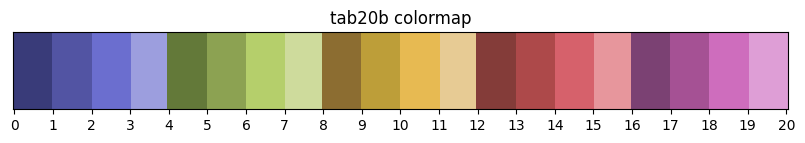

In [6]:
import matplotlib.pyplot as plt
import numpy as np
cmap = plt.get_cmap("tab20b")
fig, ax = plt.subplots(figsize=(10, 1))
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=cmap)
ax.set_title('tab20b colormap')
ax.set_yticks([])
ax.set_xticks(np.linspace(0, 255, 21))
ax.set_xticklabels([f'{i}' for i in range(21)])
plt.show()

In [19]:
import matplotlib.pyplot as plt
import math
import numpy as np
from matplotlib.ticker import MaxNLocator, MultipleLocator, FixedLocator

def filter_power_dict(data_dict, if_power, if_up):
    result = {'clean': data_dict['clean']}  # clean은 항상 포함
    for key, value in data_dict.items():
        if key == 'clean':
            continue
        try:
            power = int(key.replace('dBm', ''))
        except ValueError:
            continue
        if (if_up and power > if_power) or (not if_up and power <= if_power):
            result[key] = value
    return result

def plot_kpis_by_rsrp(test_dir, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='all', if_power=-30, if_up=True):

    df_stacked, source_order = concat_kpi(test_dir=test_dir, bin_size=bin_size)
    source_order = filter_power_dict(source_order, if_power, if_up)
    
    plot_config = {
        "DL_Tput[Mbps]": {"ylabel": "PDSCH Throughput (Mbps)", "title": "PHY Throughput"},
        "DL_MCS": {"ylabel": "DL MCS Index", "title": "MCS"},
        "CQI": {"ylabel": "CQI", "title": "CQI"},
        "SINR[dB]": {"ylabel": "SINR (dB)", "title": "SINR"},
        "RSRQ[dB]": {"ylabel": "RSRQ (dB)", "title": "RSRQ"},
        "RSSI[dBm]": {"ylabel": "RSSI (dBm)", "title": "RSSI"},
        # "DL_RB_Num": {"ylabel": "DL PRB Number(Including 0)", "title": "DL PRB Number"},
        # "RI2_Rate[%]": {"ylabel": "RI2 Rate (%)", "title": "RI2 Rate"},
        # "DL_BLER[%]": {"ylabel": "DL BLER (%)", "title": "BLER"},
    }

    df_stacked_reset = df_stacked.reset_index()
    rsrp_range = df_stacked_reset["LTE_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df_stacked_reset["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    max_val = df_stacked_reset["RSRP_Int"].max()
    min_val = df_stacked_reset["RSRP_Int"].min()
    
    rsrp_start = int(math.floor((max_val + 1) / 5.0)) * 5
    rsrp_end = int(math.ceil(min_val / 5.0)) * 5

    offset = 2
    if rsrp_class == 'high':
        rsrp_end, offset = -100, 1
    elif rsrp_class == 'low':
        rsrp_start, offset = -100, 1
    elif rsrp_class == 'edge':
        rsrp_start, offset = -120, 1
    
    xtick_labels = list(range(rsrp_start, rsrp_end-1, -5))
    df_filter = df_stacked_reset[(df_stacked_reset["RSRP_Int"] <= rsrp_start) & (df_stacked_reset["RSRP_Int"] >= rsrp_end)]

    num_needed = df_filter["IF_Power"].nunique() - 1  # clean 제외
    cmap = plt.get_cmap("tab20b")
    available_indices = np.linspace(4, 19, num=num_needed, dtype=int)
    colors = ["blue"] + [cmap(i / 20) for i in available_indices]
    markers = ['o', 's', 'D', '^', 'v', '<', '>', '*', 'P', 'X','.',',','1','2','3','4']
    # linestyles = ['-', '--', '-.', ':']
    
    n_rows, n_cols = 2, 3
    subplot_width, subplot_height = 7, 6  # 각 서브플롯 크기 (인치 단위)
    figsize = (n_cols * subplot_width, n_rows * subplot_height+1)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.subplots_adjust(hspace=0.5,wspace=0.5)
    axs = axs.flatten()

    # print(source_order)
    for i, (kpi, cfg) in enumerate(plot_config.items()):
        ax = axs[i]
        for j, source in enumerate(source_order):
            subset = df_filter[df_filter["IF_Power"] == source]
            subset = subset.sort_values(by="RSRP_Int", ascending=False)

            ax.plot(
                subset["RSRP_Int"],
                subset[kpi],
                marker=markers[j % len(markers)],
                color=colors[j % len(colors)],
                label=source,
                # linestyle=linestyles[j % len(linestyles)],
                linewidth=1,
                markersize=3
            )

        ax.set_title(cfg["title"], fontsize=15, weight="bold", pad=5)
        ax.set_xlabel("LTE RSRP [dBm]", fontsize=13)
        ax.set_ylabel(cfg["ylabel"], fontsize=13, labelpad=5)
        ax.tick_params(axis='x', labelrotation=45, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        ax.set_xticks(xtick_labels)
        ax.set_xticklabels(xtick_labels)
        ax.set_xlim(rsrp_start+offset, rsrp_end-offset)
        ax.legend(title=f"Interference Power\n({if_name})", loc="lower left", fontsize=11, title_fontsize=11)

        
        if kpi == "DL_Tput[Mbps]":
            if rsrp_class in ['low','edge']:
                y_val = 15 # 700M 커버리지 기준 값
                ax.axhline(y=y_val, color='black', linestyle='--', linewidth=1.5)
                ax.text(
                    x=ax.get_xlim()[1] + 1,   # x축 오른쪽 끝
                    y=y_val + 0.5,            # y값 약간 위
                    s=f"{y_val} Mbps",        # 표시할 텍스트
                    fontsize=11,
                    color='black',
                    verticalalignment='bottom',
                    horizontalalignment='right'
                )

        if rsrp_class in ['high', 'low', 'edge']:
            ax.xaxis.set_minor_locator(MultipleLocator(1))  # 1dB 단위 grid
            ax.xaxis.set_major_locator(FixedLocator(xtick_labels))  # 5dB 간격 tick 고정   
            ax.grid(True, which='major', axis='both', linestyle='--', linewidth=0.7, alpha=0.9)
            ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
        else:
            ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.6)

    if rsrp_class == 'all':
        fig.suptitle(f"{test_dir}: DL KPI Trends [RSRP Full Range]", fontsize=18, weight='bold', y=1.0)
    elif rsrp_class == 'high':
        fig.suptitle(f"{test_dir}: DL KPI Trends [RSRP ≥ {rsrp_end} dBm]", fontsize=18, weight='bold', y=1.0)
    elif rsrp_class == 'low':
        fig.suptitle(f"{test_dir}: DL KPI Trends [RSRP ≤ {rsrp_start} dBm]", fontsize=18, weight='bold', y=1.0)
    elif rsrp_class == 'edge':
        fig.suptitle(f"{test_dir}: DL KPI Trends [RSRP ≤ {rsrp_start} dBm]", fontsize=18, weight='bold', y=1.0)

    plt.tight_layout()

    output_path = os.path.join(test_dir, f"{test_dir}_rsrp_{rsrp_class}.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.3)

    plt.show()

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import os
import numpy as np

def plot_logscale_throughput(test_dir, bin_size, if_name, rsrp_start, rsrp_end):
    df_stacked, source_order_raw = concat_kpi(test_dir=test_dir, bin_size=bin_size)
    source_order = ['clean'] + [s for s in source_order_raw if s != 'clean']
    df = df_stacked.reset_index()

    rsrp_range = df["LTE_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    df_filter = df[
        (df["RSRP_Int"] <= rsrp_start) & (df["RSRP_Int"] >= rsrp_end)
    ]

    offset = 1
    xtick_labels = list(range(rsrp_start, rsrp_end - 1, -1 if (rsrp_start - rsrp_end) <= 10 else -5))

    num_needed = len(source_order) - 1
    cmap = plt.get_cmap("tab20b")
    colors = ["blue"] + [cmap(i / 20) for i in np.linspace(4, 19, num=num_needed, dtype=int)]
    markers = ['o', 's', 'D', '^', 'v', '<', '>', '*', 'P', 'X', '.', ',', '1', '2', '3', '4']

    fig, ax = plt.subplots(figsize=(7, 6))

    for i, source in enumerate(source_order):
        subset = df_filter[df_filter["IF_Power"] == source].sort_values(by="RSRP_Int", ascending=False)
        ax.plot(
            subset["RSRP_Int"],
            subset["DL_Tput[Mbps]"],
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=source,
            linewidth=1,
            markersize=3
        )

    ax.set_title("DL Throughput: Log Scale Comparison", fontsize=11, weight='bold')
    ax.set_xlabel("LTE RSRP [dBm]", fontsize=11)
    ax.set_ylabel("PDSCH Throughput (Mbps, log)", fontsize=11)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(LogFormatter(labelOnlyBase=False))
    ax.set_xticks(xtick_labels)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlim(rsrp_start + offset, rsrp_end - offset)
    ax.tick_params(axis='x', labelrotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.9)

    y_val = 15
    ax.axhline(y=y_val, color='black', linestyle='--', linewidth=1.5)
    ax.text(x=ax.get_xlim()[1] + 1, y=y_val * 1.05, s=f"{y_val} Mbps",
            fontsize=10, color='black', va='bottom', ha='right')

    ax.legend(title=f"Interference\n({if_name})", loc="lower left", fontsize=9, title_fontsize=9)
    fig.suptitle(f"{test_dir} [RSRP {rsrp_start} ~ {rsrp_end} dBm]", fontsize=13, weight='bold', y=0.97)

    output_path = os.path.join(test_dir, f"{test_dir}_Tput_LogScale.png")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


def plot_relative_throughput(test_dir, bin_size, if_name, rsrp_start, rsrp_end):
    df_stacked, source_order_raw = concat_kpi(test_dir=test_dir, bin_size=bin_size)
    source_order = ['clean'] + [s for s in source_order_raw if s != 'clean']
    df = df_stacked.reset_index()

    rsrp_range = df["LTE_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    df_filter = df[
        (df["RSRP_Int"] <= rsrp_start) & (df["RSRP_Int"] >= rsrp_end)
    ]

    offset = 1
    xtick_labels = list(range(rsrp_start, rsrp_end - 1, -1 if (rsrp_start - rsrp_end) <= 10 else -5))

    num_needed = len(source_order) - 1
    cmap = plt.get_cmap("tab20b")
    colors = ["blue"] + [cmap(i / 20) for i in np.linspace(4, 19, num=num_needed, dtype=int)]
    markers = ['o', 's', 'D', '^', 'v', '<', '>', '*', 'P', 'X', '.', ',', '1', '2', '3', '4']

    df_clean = df_filter[df_filter["IF_Power"] == "clean"]
    clean_mean_by_rsrp = df_clean.groupby("RSRP_Int")["DL_Tput[Mbps]"].mean()

    fig, ax = plt.subplots(figsize=(7, 6))

    for i, source in enumerate(source_order):
        subset = df_filter[df_filter["IF_Power"] == source]
        grouped = subset.groupby("RSRP_Int")["DL_Tput[Mbps]"].mean()

        if source == "clean":
            ax.plot(
                grouped.index,
                [100] * len(grouped),
                marker=markers[i % len(markers)],
                color=colors[i % len(colors)],
                label="clean",
                linewidth=1.5,
                markersize=3
            )
        else:
            relative = (grouped / clean_mean_by_rsrp).dropna() * 100
            ax.plot(
                relative.index,
                relative.values,
                marker=markers[i % len(markers)],
                color=colors[i % len(colors)],
                label=source,
                linewidth=1,
                markersize=3
            )

    ax.set_title("DL Throughput: Relative Comparison (% of Clean)", fontsize=11, weight='bold')
    ax.set_xlabel("LTE RSRP [dBm]", fontsize=11)
    ax.set_ylabel("Relative Throughput (%)", fontsize=11)
    ax.set_ylim(0, 120)
    ax.set_xticks(xtick_labels)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlim(rsrp_start + offset, rsrp_end - offset)
    ax.tick_params(axis='x', labelrotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.9)

    ax.legend(title=f"Interference\n({if_name})", loc="lower left", fontsize=9, title_fontsize=9)

    fig.suptitle(f"{test_dir} [RSRP {rsrp_start} ~ {rsrp_end} dBm]", fontsize=13, weight='bold', y=0.97)
    output_path = os.path.join(test_dir, f"{test_dir}_Tput_Relative.png")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

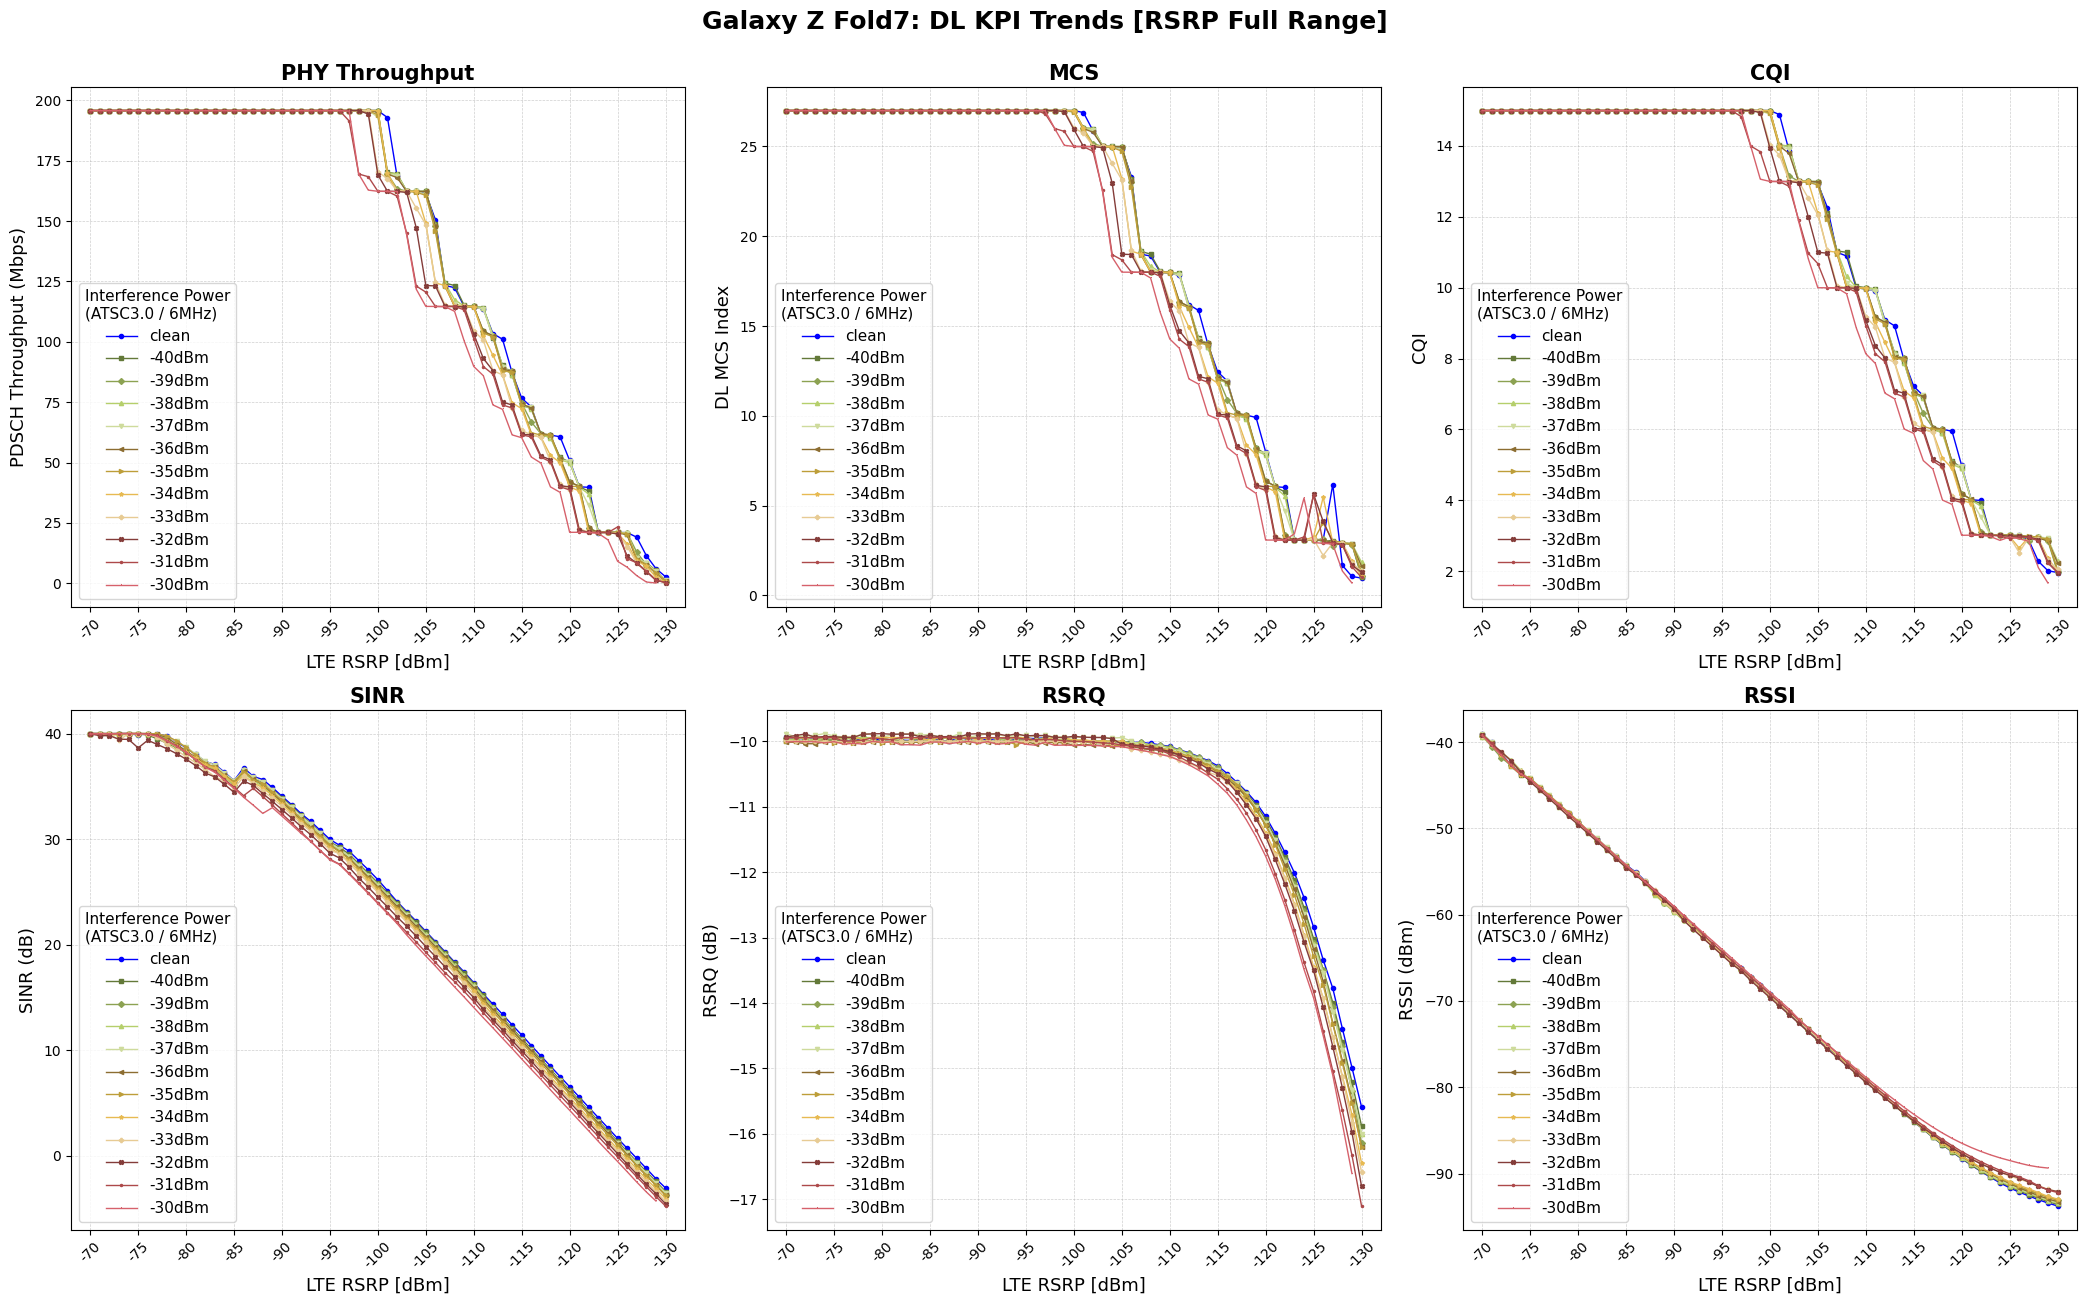

In [24]:
test_cases = ["Galaxy Z Fold7"]
if_type = "ATSC3.0 / 6MHz"
for test_case in test_cases:
    plot_kpis_by_rsrp(test_dir=test_case, bin_size=1, if_name=if_type, rsrp_class='all', if_power=-30, if_up=False)

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import math
import os

def filter_power_dict(data_dict, if_power, if_up):
    result = {'clean': data_dict['clean']}
    for key, value in data_dict.items():
        if key == 'clean':
            continue
        try:
            power = int(key.replace('dBm', ''))
        except ValueError:
            continue
        if (if_up and power > if_power) or (not if_up and power <= if_power):
            result[key] = value
    return result

def plot_tput_absolute_and_relative(test_dir, bin_size=1, if_name="ATSC3.0 / 6MHz",
                                    if_power=-30, if_up=True, rsrp_min=None):
    df_stacked, source_order_raw = concat_kpi(test_dir=test_dir, bin_size=bin_size)
    source_order = filter_power_dict(source_order_raw, if_power, if_up)

    df = df_stacked.reset_index()
    rsrp_range = df["LTE_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    df = df[df["IF_Power"].isin(source_order.keys())]
    if rsrp_min is not None:
        df = df[df["RSRP_Int"] >= rsrp_min]

    max_val = df["RSRP_Int"].max()
    min_val = df["RSRP_Int"].min()

    rsrp_start = int(math.floor((max_val + 1) / 5.0)) * 5
    rsrp_end = int(math.ceil(min_val / 5.0)) * 5
    offset = 2

    xtick_labels = list(range(rsrp_start, rsrp_end - 1, -5))
    df_filter = df[(df["RSRP_Int"] <= rsrp_start) & (df["RSRP_Int"] >= rsrp_end)]

    # ✅ 모든 RSRP_Int 포함 (1dB 단위 유지)
    abs_df = df_filter.groupby(["RSRP_Int", "IF_Power"])["DL_Tput[Mbps]"].mean().unstack()
    rel_df = abs_df.divide(abs_df["clean"], axis=0) * 100

    num_needed = len(source_order) - 1
    cmap = plt.get_cmap("tab20b")
    colors = ["blue"] + [cmap(i / 20) for i in np.linspace(4, 19, num=num_needed, dtype=int)]
    markers = ['o', 's', 'D', '^', 'v', '<', '>', '*', 'P', 'X', '.', ',', '1', '2', '3', '4']

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    plt.subplots_adjust(wspace=0.5, hspace=0.3)
    ax1, ax2 = axs.flatten()

    # ➤ 1. 절대값 (Mbps)
    for i, source in enumerate(source_order):
        if source not in abs_df.columns:
            continue
        ax1.plot(
            abs_df.index,
            abs_df[source],
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=source,
            linewidth=1,
            markersize=3
        )
    ax1.set_title("DL Throughput (Mbps)", fontsize=14, weight='bold')
    ax1.set_xlabel("RSRP [dBm]", fontsize=12)
    ax1.set_ylabel("Throughput", fontsize=12)
    ax1.set_xticks(xtick_labels)
    ax1.set_xticklabels(xtick_labels, rotation=45)
    ax1.set_xlim(rsrp_start + offset, rsrp_end - offset)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(title=f"Interference\n({if_name})", loc="lower left", fontsize=9, title_fontsize=9)

    # ➤ 2. 상대값 (%)
    for i, source in enumerate(source_order):
        if source == "clean" or source not in rel_df.columns:
            continue
        ax2.plot(
            rel_df.index,
            rel_df[source],
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=source,
            linewidth=1,
            markersize=3
        )
    ax2.axhline(100, color='gray', linestyle='--', linewidth=1)
    ax2.set_title("Relative Tput (% of Clean)", fontsize=14, weight='bold')
    ax2.set_xlabel("RSRP [dBm]", fontsize=12)
    ax2.set_ylabel("Relative Throughput (%)", fontsize=12)
    ax2.set_xticks(xtick_labels)
    ax2.set_xticklabels(xtick_labels, rotation=45)
    ax2.set_xlim(rsrp_start + offset, rsrp_end - offset)
    ax2.set_ylim(0, 120)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(title=f"Interference\n({if_name})", loc="lower left", fontsize=9, title_fontsize=9)

    fig.suptitle(f"{test_dir} (UHD Power {'over' if if_up else 'under'} {if_power} dBm)", fontsize=15, weight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    output_path = os.path.join(test_dir, f"{test_dir}_UHD_{'over' if if_up else 'under'}{if_power}dBm.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

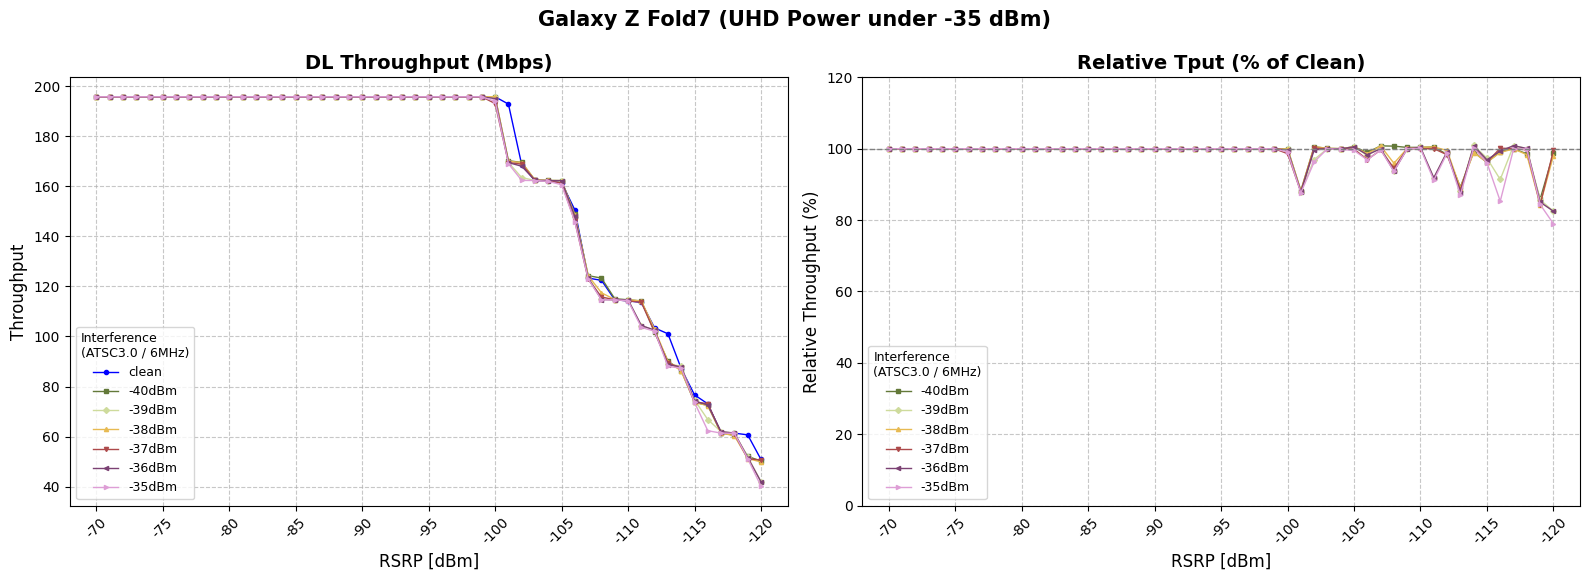

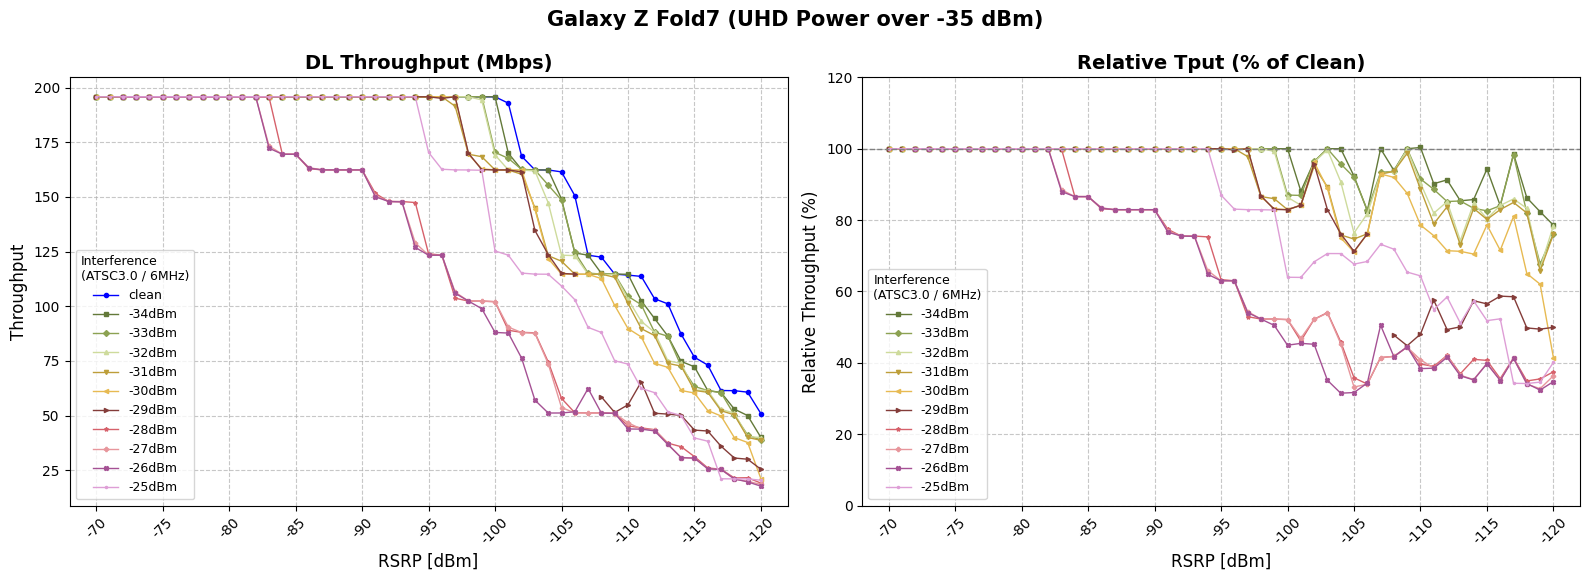

In [67]:
test_cases = ["Galaxy Z Fold7"]
if_type = "ATSC3.0 / 6MHz"

for test_case in test_cases:
    plot_tput_absolute_and_relative(test_dir=test_case, bin_size=1, if_name=if_type, if_power=-35, if_up=False, rsrp_min=-120)
    plot_tput_absolute_and_relative(test_dir=test_case, bin_size=1, if_name=if_type, if_power=-35, if_up=True, rsrp_min=-120)
    # plot_tput_absolute_and_relative(test_dir=test_case, bin_size=1, if_name=if_type, if_power=-30, if_up=False, rsrp_min=-120)
    # plot_tput_absolute_and_relative(test_dir=test_case, bin_size=1, if_name=if_type, if_power=-30, if_up=True, rsrp_min=-120)